In [1]:
from signal_processing import *
from util import *

from ast import literal_eval
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import pyabf
import numpy as np
import pickle
import pandas as pd
import sys
from datetime import datetime, timedelta
from pathlib import Path
import scipy.signal as signal
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import linregress

#%matplotlib ipympl

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

# Optional: Set a default font size
plt.rcParams["font.size"] = 10

In [64]:
#file_path = "oncell_spike_dicts_20251016.pickle"
file_path = "oncell_spike_dicts_20260317.pickle"
with open(file_path, 'rb') as file:
    # Load the data from the pickle file
    all_cell_dict = pickle.load(file)

In [65]:
cell_manifest = pd.read_excel('data/DAN_glu_uncaging.xlsx', sheet_name='cells')
cell_manifest['file_list'] = cell_manifest['file_list'].apply(literal_eval)

In [66]:
sham_df = cell_manifest[cell_manifest['mouse_treatment']=='sham']
SNI_df = cell_manifest[cell_manifest['mouse_treatment']=='SNI']
df_list = [sham_df, SNI_df]
c_list = ['blue', 'red']

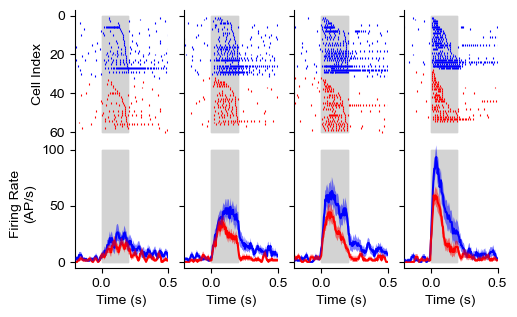

In [67]:
bin_w = 0.005
hist_smooth = 5
start, stop = -0.2, 0.5

hist_bins = np.arange(start, stop+bin_w, bin_w)

df_list = [sham_df, SNI_df]
c_list = ['blue', 'red']
label_list = ["SHAM", "SNI"]
target_powers = [0.5, 1.5, 2.5, 3.5]
power_tol = 0.5
plot_it = 0
plotted_dfs = []##to be used to ID example traces
fig, axes = plt.subplots(nrows=2, ncols=len(target_powers), 
                         sharex=True, sharey='row', height_ratios=[1,1], figsize=(5,3))
## for each power range
for target_power in target_powers:
        
        
    marker_it = 0
    ##for each category
    for df, color in zip(df_list, c_list):
        ##lists to append plotted data onto
        last_AP_times = []
        cell_names = []
        sweep_names = []
        all_hists = []
        all_spikes = []

        ##for each cell in this category
        for cell_name in df['cell_name'].values:
            ##dictionary of cell data
            cell_dict = all_cell_dict[cell_name]
            ##dataframe of sweep features (controled (e.g. power) and measured (e.g. number of spikes))
            sweep_feat_df = cell_dict['sweep_feats']
            ##subset for sweeps near target power
            target_sweeps = sweep_feat_df[abs(sweep_feat_df['UV_power'] - target_power) <= power_tol].copy()
            ##if there's at least one sweep in the target range
            if len(target_sweeps) > 0:
                ##use the first one
                ts = target_sweeps['sweep_name'].iloc[0]
                ##data frame of detected spikes, times, heights...
                spike_df = cell_dict[ts]['spike_df']
                ##offset by timing of light pulse
                spike_times = spike_df['v_peak_times'].values - cell_dict[ts]['dig_onset']
                ##add cell data to lists
                last_AP_times.append(target_sweeps['stim_max_latency'].iloc[0])
                all_spikes.append(spike_times)
                cell_names.append(cell_name)
                sweep_names.append(ts)
                t_y, t_x = np.histogram(spike_times, bins=hist_bins)
                t_y_smooth = smooth_moving_average(t_y, hist_smooth)
                all_hists.append(t_y_smooth)
                
        ##put collected values into dataframe, sort by time of last AP
        to_plot_df = pd.DataFrame({'last_AP':last_AP_times, 'spike_times':all_spikes, 
                                   'cell_names':cell_names, 'sweep_names':sweep_names})
        to_plot_df.sort_values(by=['last_AP'], inplace=True, ascending=True)
        ##iterate through and plot spike times in order
        for sts in to_plot_df['spike_times'].values:
            marker_it += 1
            axes[0, plot_it].eventplot(sts, orientation='horizontal', lineoffset=marker_it, color=color, linewidth=0.8)
        ##save plotted info for finding example traces
        plotted_dfs.append(to_plot_df)
        ##make per cell histograms a 2d array
        class_count = len(all_hists)
        hist_array = np.array(all_hists)
        ##mean rate = avg number of spikes / bin window
        mean_rate = np.mean(hist_array, axis=0)/bin_w
        std_rate = np.std(hist_array, axis=0, ddof=1)/bin_w
        se_rate = std_rate / np.sqrt(class_count)
        axes[1, plot_it].plot(t_x[:-1] + 0.5*bin_w, mean_rate, color=color)
        axes[1, plot_it].fill_between(t_x[:-1] + 0.5*bin_w, mean_rate + se_rate, mean_rate - se_rate, color=color, alpha=0.5, zorder=3, ec=None)
        #axes[1].errorbar(t_x[:-1] + 0.5*bin_w, mean_rate, yerr=se_rate, color=color, lw=1)
        axes[0, plot_it].fill_between([0, 0.2], [0, 0], [60, 60], color='lightgrey', zorder=1)
        axes[1, plot_it].fill_between([0, 0.2], [0, 0], [100, 100], color='lightgrey', zorder=1)
    plot_it += 1
axes[0, 0].set_xlim([start, stop])
axes[1, 0].set_ylabel('Firing Rate\n(AP/s)')
axes[0, 0].set_ylabel('Cell Index')      
cell_ylim = axes[0, 0].get_ylim()
axes[0, 0].set_ylim(cell_ylim[1], cell_ylim[0])
for col in range(len(target_powers)):
    axes[0, col].tick_params(axis='x', bottom=False, labelbottom=False)
    axes[0, col].spines['bottom'].set_visible(False)
    axes[1, col].set_xlabel('Time (s)')
    for row in range(2):
        axes[row, col].spines[['right', 'top']].set_visible(False)
plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)

In [68]:
def stats_by_cell_and_bin(source_df, x_param, x_bins, all_cell_dict=all_cell_dict):
    """Given source_df with cell_names, go through, bin data by x_param, average all numerical columns to make
    binned_df"""
    cell_bs_list = []
    for cell_name in source_df['cell_name'].values:        
        cell_dict = all_cell_dict[cell_name]
        sweep_feat_df = cell_dict['sweep_feats']
        sweep_feat_df['x_bin'] = pd.cut(sweep_feat_df[x_param], bins=x_bins, right=False)
        bin_stats = sweep_feat_df.groupby('x_bin').mean(numeric_only=True)
        cell_bs_list.append(bin_stats)
    ##make a dataframe where number of rows = #bins * #cells    
    binned_cells_df = pd.concat(cell_bs_list)
    mean_df = binned_cells_df.groupby('x_bin').mean()
    std_df = binned_cells_df.groupby('x_bin').std()
    se_df = binned_cells_df.groupby('x_bin').sem()
    return {'mean_df':mean_df,
    'std_df':std_df,
    'se_df':se_df}
power_bins = np.arange(0, 4.1, 1)
UVpower_binstats_sham = stats_by_cell_and_bin(sham_df, 'UV_power', power_bins)
UVpower_binstats_SNI = stats_by_cell_and_bin(SNI_df, 'UV_power', power_bins)

In [69]:
def plot_binned_vals(binstats, x_param, y_param, ax=None, color='black', y_scale=1, sem_filt=True):

    if ax == None:
        fig, ax = plt.subplots()

    x_vals = binstats['mean_df'][x_param]
    y_vals = binstats['mean_df'][y_param] * y_scale
    y_sem = binstats['se_df'][y_param] * y_scale

    if sem_filt:
        is_not_nan = ~np.isnan(y_sem)
        x_vals = x_vals[is_not_nan]
        y_vals = y_vals[is_not_nan]
        y_sem = y_sem[is_not_nan]
    
    
    ax.plot(x_vals,  y_vals, c=color, marker='s', alpha=1)
    ax.fill_between(x_vals, y_vals - y_sem, y_vals + y_sem, color=color, alpha=0.5, ec=None)



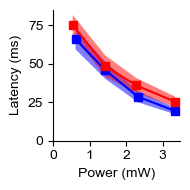

In [70]:
fig, ax = plt.subplots(figsize=(2,2))
plot_binned_vals(UVpower_binstats_sham, 'UV_power', 'stim_min_latency', color='blue', y_scale=1000, ax=ax)
plot_binned_vals(UVpower_binstats_SNI, 'UV_power', 'stim_min_latency', color='red', y_scale=1000, ax=ax)
xlims = ax.get_xlim()
ylims = ax.get_ylim()
ax.set_xlim([0, xlims[1]])
ax.set_ylim([0, ylims[1]])
ax.set_ylabel('Latency (ms)')
ax.set_xlabel('Power (mW)')
ax.spines[['right', 'top']].set_visible(False)
ax.xaxis.set_major_locator(MaxNLocator(4))
plt.tight_layout()

In [71]:
UVpower_binstats_sham['mean_df'].columns

Index(['UV_perc', 'UV_power', 'dig_onset', 'dig_offset', 'stim_max',
       'stim_mean', 'stim_first', 'duration', 'first_isi', 'stim_max_latency',
       'stim_min_latency', 'n_50ms', 'n_early', 'n_late', 'n_stim', 'n_off',
       'rh_early', 'rh_late', 'rdv_early', 'rdv_late', 'pre_mean', 'rh_min',
       'dv_min', 'spike1_rh', 'spike3_rh', 'spike5_rh', 'spike8_rh',
       'spike10_rh', 'spike15_rh', 'spike20_rh'],
      dtype='object')

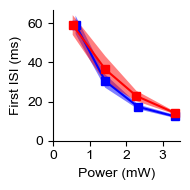

In [72]:
fig, ax = plt.subplots(figsize=(2,2))
plot_binned_vals(UVpower_binstats_sham, 'UV_power', 'first_isi', y_scale=1000, color='blue', ax=ax)
plot_binned_vals(UVpower_binstats_SNI, 'UV_power', 'first_isi', y_scale=1000, color='red', ax=ax)
xlims = ax.get_xlim()
ylims = ax.get_ylim()
ax.set_xlim([0, xlims[1]])
ax.set_ylim([0, ylims[1]])
ax.set_ylabel('First ISI (ms)')
ax.set_xlabel('Power (mW)')
ax.spines[['right', 'top']].set_visible(False)
ax.xaxis.set_major_locator(MaxNLocator(4))
plt.tight_layout()

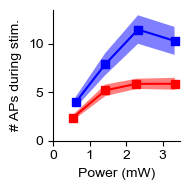

In [73]:
fig, ax = plt.subplots(figsize=(2,2))
plot_binned_vals(UVpower_binstats_sham, 'UV_power', 'n_stim', y_scale=1, color='blue', ax=ax)
plot_binned_vals(UVpower_binstats_SNI, 'UV_power', 'n_stim', y_scale=1, color='red', ax=ax)
xlims = ax.get_xlim()
ylims = ax.get_ylim()
ax.set_xlim([0, xlims[1]])
ax.set_ylim([0, ylims[1]])
ax.set_ylabel('# APs during stim.')
ax.set_xlabel('Power (mW)')
ax.spines[['right', 'top']].set_visible(False)
ax.xaxis.set_major_locator(MaxNLocator(4))
plt.tight_layout()

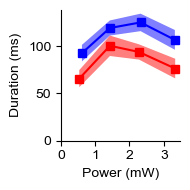

In [75]:
fig, ax = plt.subplots(figsize=(2,2))
y_param = 'duration'
plot_binned_vals(UVpower_binstats_sham, 'UV_power', y_param, y_scale=1000, color='blue', ax=ax)
plot_binned_vals(UVpower_binstats_SNI, 'UV_power', y_param, y_scale=1000, color='red', ax=ax)
xlims = ax.get_xlim()
ylims = ax.get_ylim()
ax.set_xlim([0, xlims[1]])
ax.set_ylim([0, ylims[1]])
ax.set_ylabel('Duration (ms)')
ax.set_xlabel('Power (mW)')
ax.spines[['right', 'top']].set_visible(False)
ax.xaxis.set_major_locator(MaxNLocator(4))
plt.tight_layout()

In [76]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [85]:
##create a dataframe for 2-way anova comparing relationship between plotted parameters 
##above and power for Sham and SNI groups. Each row represents average values measured 
##for one cell within the defined power_bins. This step makes sure that cells with 
##multiple measurements within a power bin are only represented once (as the mean
##value)

df_list = [sham_df, SNI_df]
c_list = ['blue', 'red']
label_list = ["SHAM", "SNI"]

df_list_stats = []
x_param = 'UV_power'
power_bins = np.arange(0, 4.1, 1)
for df, cond in zip(df_list, label_list):
    cond_list = []
    ##for each cell
    for cell_name in df['cell_name'].values:
        ## get the dataframe of response features
        cell_dict = all_cell_dict[cell_name]
        sweep_feat_df = cell_dict['sweep_feats']
        ##bin data for each cell, and generated average 
        sweep_feat_df['x_bin'] = pd.cut(sweep_feat_df[x_param], bins=power_bins, right=False)
        bin_stats = sweep_feat_df.groupby('x_bin').mean(numeric_only=True)
        cond_list.append(bin_stats)

    cond_df = pd.concat(cond_list)
    cond_df['condition'] = cond
    df_list_stats.append(cond_df)


df_stats = pd.concat(df_list_stats)

In [86]:

formula = 'stim_min_latency ~ condition + UV_power + condition:UV_power'
model = ols(formula, df_stats).fit()

anova_results = anova_lm(model, typ=2)


anova_results

,sum_sq,df,F,PR(>F)
condition,0.001956,1.0,2.427324,1.206417e-01
UV_power,0.065433,1.0,81.189625,9.017079e-17
condition:UV_power,0.000084,1.0,0.104133,7.472248e-01
Residual,0.181334,225.0,NaN,NaN


In [87]:
formula = 'first_isi ~ condition + UV_power + condition:UV_power'
model = ols(formula, df_stats).fit()

anova_results = anova_lm(model, typ=2)


anova_results

,sum_sq,df,F,PR(>F)
condition,0.000410,1.0,1.080197,2.998319e-01
UV_power,0.053380,1.0,140.650884,3.045554e-25
condition:UV_power,0.000085,1.0,0.223352,6.369816e-01
Residual,0.080839,213.0,NaN,NaN


In [88]:
formula = 'n_stim ~ condition + UV_power + condition:UV_power'
model = ols(formula, df_stats).fit()

anova_results = anova_lm(model, typ=2)


anova_results

,sum_sq,df,F,PR(>F)
condition,721.845618,1.0,26.498106,5.710468e-07
UV_power,769.142063,1.0,28.234303,2.563171e-07
condition:UV_power,80.446547,1.0,2.953098,8.707653e-02
Residual,6183.798806,227.0,NaN,NaN


In [89]:
formula = 'duration ~ condition + UV_power + condition:UV_power'
model = ols(formula, df_stats).fit()

anova_results = anova_lm(model, typ=2)


anova_results

,sum_sq,df,F,PR(>F)
condition,0.041288,1.0,15.951668,0.000088
UV_power,0.005620,1.0,2.171266,0.142008
condition:UV_power,0.000219,1.0,0.084522,0.771528
Residual,0.582377,225.0,NaN,NaN
